# Efficiency reweighting
## Use ```hep_ml``` to reweight LHCb MC based on AmpGen samples to find the efficiency

### Import the necessary libraries

In [1]:
import numpy as np
import uproot
from hep_ml import reweight
from hep_ml.metrics_utils import ks_2samp_weighted
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
import pickle

### Load files and ```TTree```

In [2]:
AmpGenFile = uproot.open('/data/bes3/tat/KKpipi_StrongPhase_Analysis_cisi/ReweighterSamples/D02KKpipi_D0.root')
AmpGenTree = AmpGenFile['DalitzTree']
AmpGenCPEvenFile = uproot.open('/data/bes3/tat/KKpipi_StrongPhase_Analysis_cisi/ReweighterSamples/D02KKpipi_CPEven.root')
AmpGenCPEvenTree = AmpGenCPEvenFile['DalitzTree']
AmpGenCPOddFile = uproot.open('/data/bes3/tat/KKpipi_StrongPhase_Analysis_cisi/ReweighterSamples/D02KKpipi_CPOdd.root')
AmpGenCPOddTree = AmpGenCPOddFile['DalitzTree']

### Load branches as ```pandas``` arrays

In [3]:
AmpGenArray = AmpGenTree.arrays(library = 'pd', filter_name='s*')
AmpGenArray.sort_index(axis=1, inplace=True)
AmpGenCPEvenArray = AmpGenCPEvenTree.arrays(library = 'pd', filter_name='s*')
AmpGenCPEvenArray.sort_index(axis=1, inplace=True)
AmpGenCPOddArray = AmpGenCPOddTree.arrays(library = 'pd', filter_name='s*')
AmpGenCPOddArray.sort_index(axis=1, inplace=True)

In [4]:
if False:
    AmpGenArray = AmpGenArray[0:10000]
    AmpGenCPEvenArray = AmpGenCPEvenArray[0:10000]
    AmpGenCPOddArray = AmpGenCPOddArray[0:10000]

### Split samples into test and training

In [5]:
AmpGenArray_train, AmpGenArray_test = train_test_split(AmpGenArray)
AmpGenCPEvenArray_train, AmpGenCPEvenArray_test = train_test_split(AmpGenCPEvenArray)
AmpGenCPOddArray_train, AmpGenCPOddArray_test = train_test_split(AmpGenCPOddArray)

### Train reweighting algorithm

In [6]:
reweighter_CPEven = reweight.GBReweighter(n_estimators=150, min_samples_leaf=1000)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reweighter_CPEven.fit(AmpGenArray_train, AmpGenCPEvenArray_train)
BES3Weights_CPEven = reweighter_CPEven.predict_weights(AmpGenArray_test)

In [7]:
reweighter_CPOdd = reweight.GBReweighter(n_estimators=150, min_samples_leaf=1000)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reweighter_CPOdd.fit(AmpGenArray_train, AmpGenCPOddArray_train)
BES3Weights_CPOdd = reweighter_CPOdd.predict_weights(AmpGenArray_test)

### Variables to look at

In [8]:
Variables = {'s01' : 'K^+K^-', 's03' : 'K^+\pi^-', 's12' : 'K^-\pi^+', 's23' : '\pi^+\pi^-', 's012' : 'K^+K^-\pi^+'}

### Check Kolmogorov-Smirnov distance for 1D projections before reweighting

In [9]:
for key in Variables:
    print('KS over ', key, ': ', ks_2samp_weighted(AmpGenCPEvenArray_test[key], AmpGenArray_test[key], weights1 = np.ones(len(AmpGenCPEvenArray_test), dtype=float), weights2 = np.ones(len(AmpGenArray_test), dtype=float)))

KS over  s01 :  0.03535000000003541
KS over  s03 :  0.03501000000003507
KS over  s12 :  0.03428000000003428
KS over  s23 :  0.10417000000010418
KS over  s012 :  0.03631000000003637


In [10]:
for key in Variables:
    print('KS over ', key, ': ', ks_2samp_weighted(AmpGenCPOddArray_test[key], AmpGenArray_test[key], weights1 = np.ones(len(AmpGenCPOddArray_test), dtype=float), weights2 = np.ones(len(AmpGenArray_test), dtype=float)))

KS over  s01 :  0.09531000000009537
KS over  s03 :  0.04873000000004879
KS over  s12 :  0.054210000000054215
KS over  s23 :  0.28999000000029007
KS over  s012 :  0.12467000000012474


### Plot 1D projections before reweighting

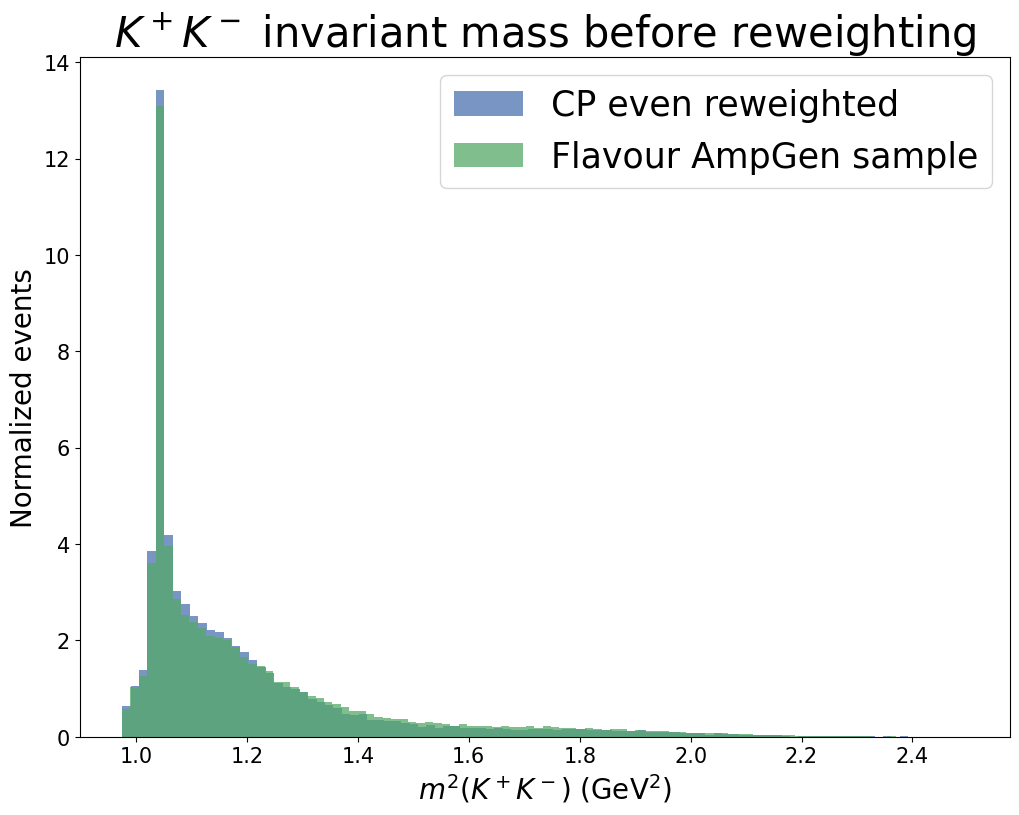

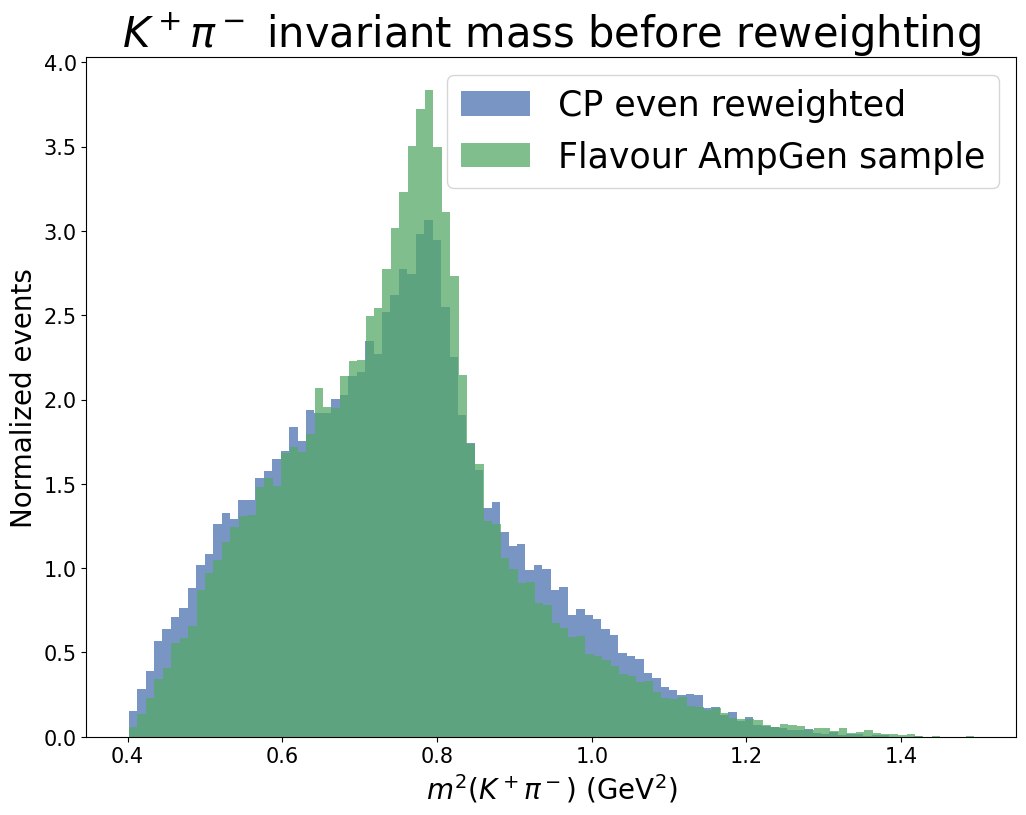

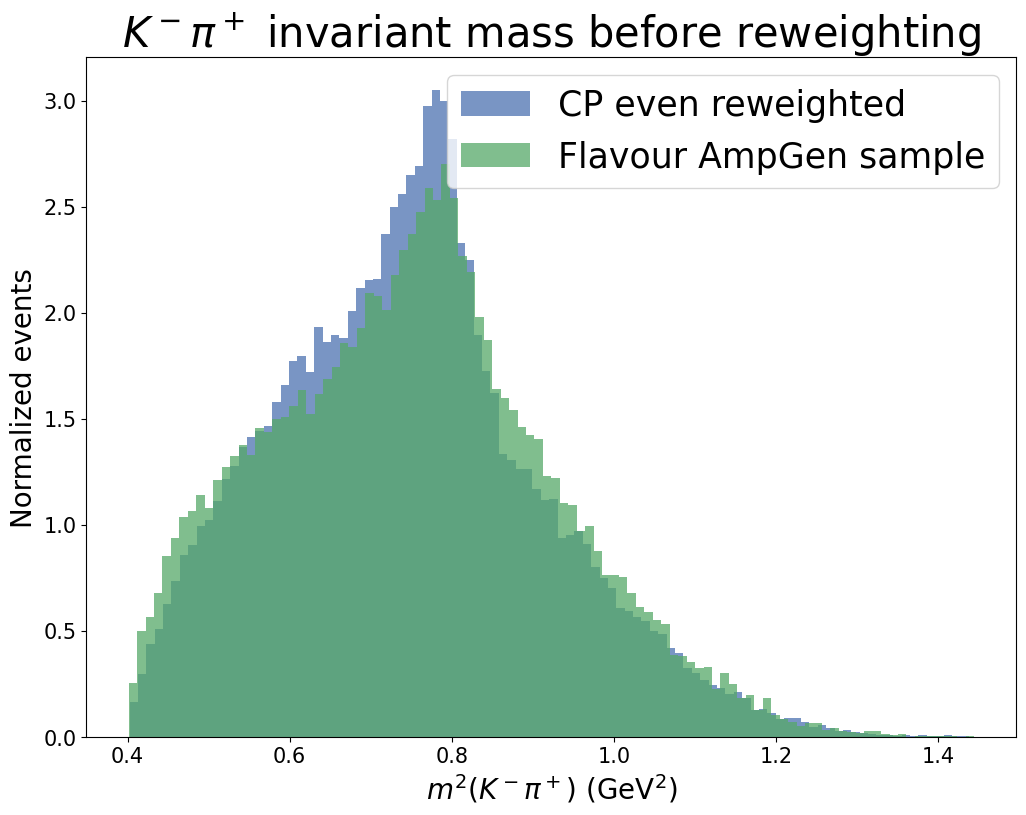

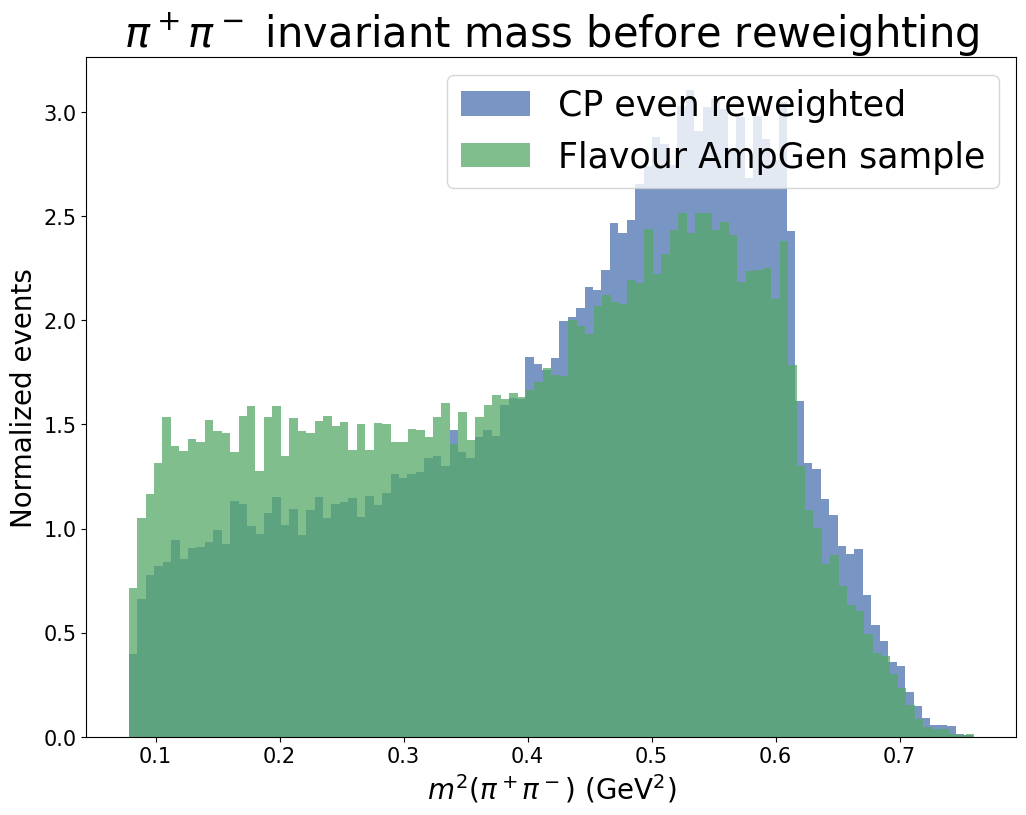

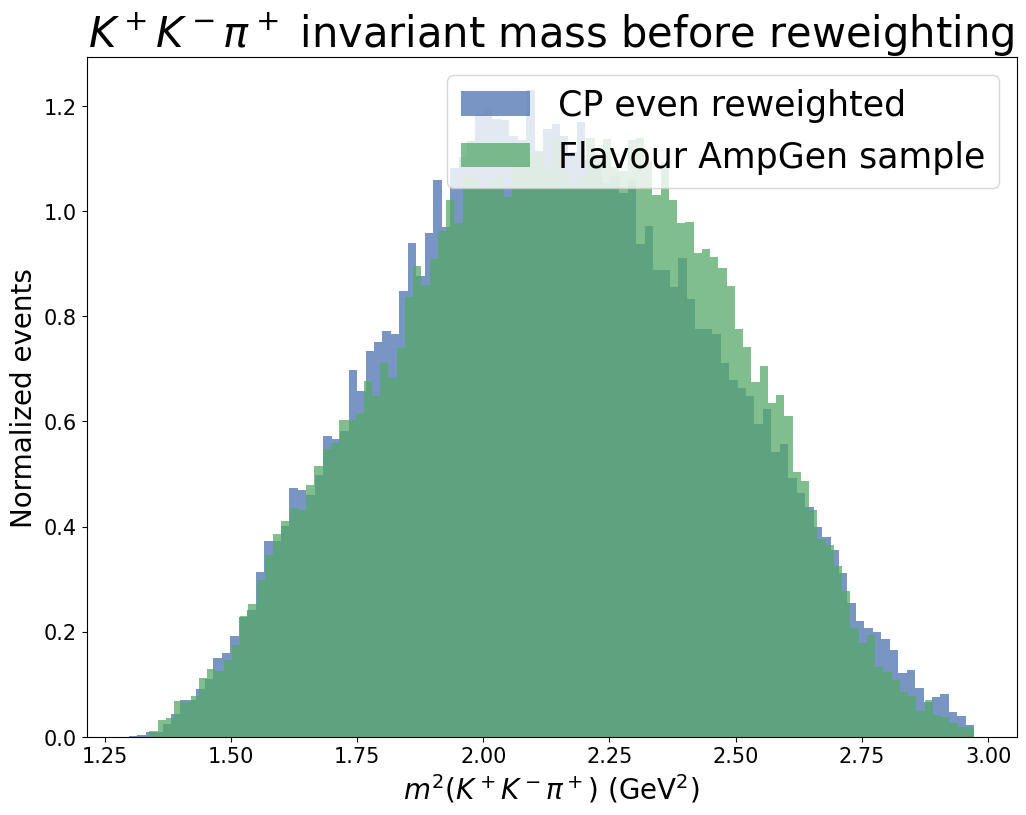

In [11]:
for key, value in Variables.items():
    plt.figure(figsize=(12, 9), dpi=100)
    plt.style.use('seaborn-deep')
    dummy = plt.hist(AmpGenCPEvenArray_test[key], bins = 100, density = True, alpha = 0.75, label = 'CP even reweighted')
    dummy = plt.hist(AmpGenArray_test[key], bins = 100, density = True, alpha = 0.75, label = 'Flavour AmpGen sample')
    plt.legend(loc='upper right', fontsize = 25)
    dummy = plt.title(r'$' + value + '$ invariant mass before reweighting', fontsize = 30)
    dummy = plt.xlabel(r'$m^2(' + value + ')$ (GeV$^2$)', fontsize = 20)
    dummy = plt.ylabel('Normalized events', fontsize = 20)
    dummy = plt.xticks(fontsize = 15)
    dummy = plt.yticks(fontsize = 15)
    plt.savefig(key + '_BeforeReweighting_CPEven.png')
    plt.show()

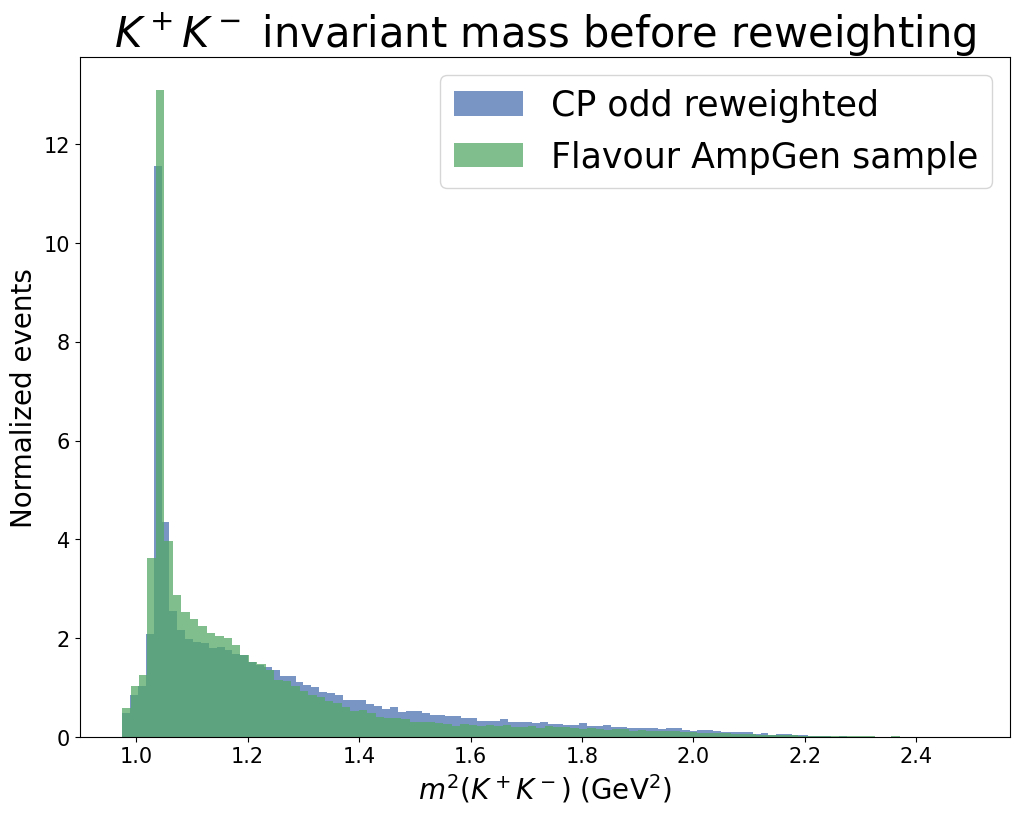

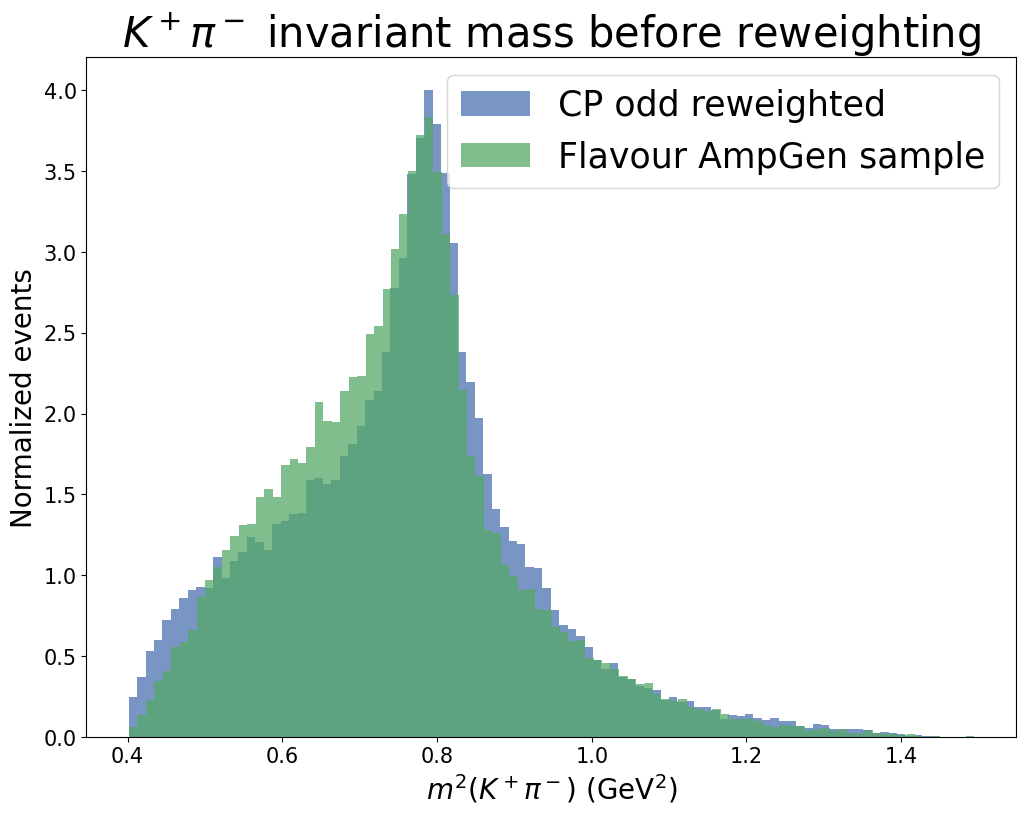

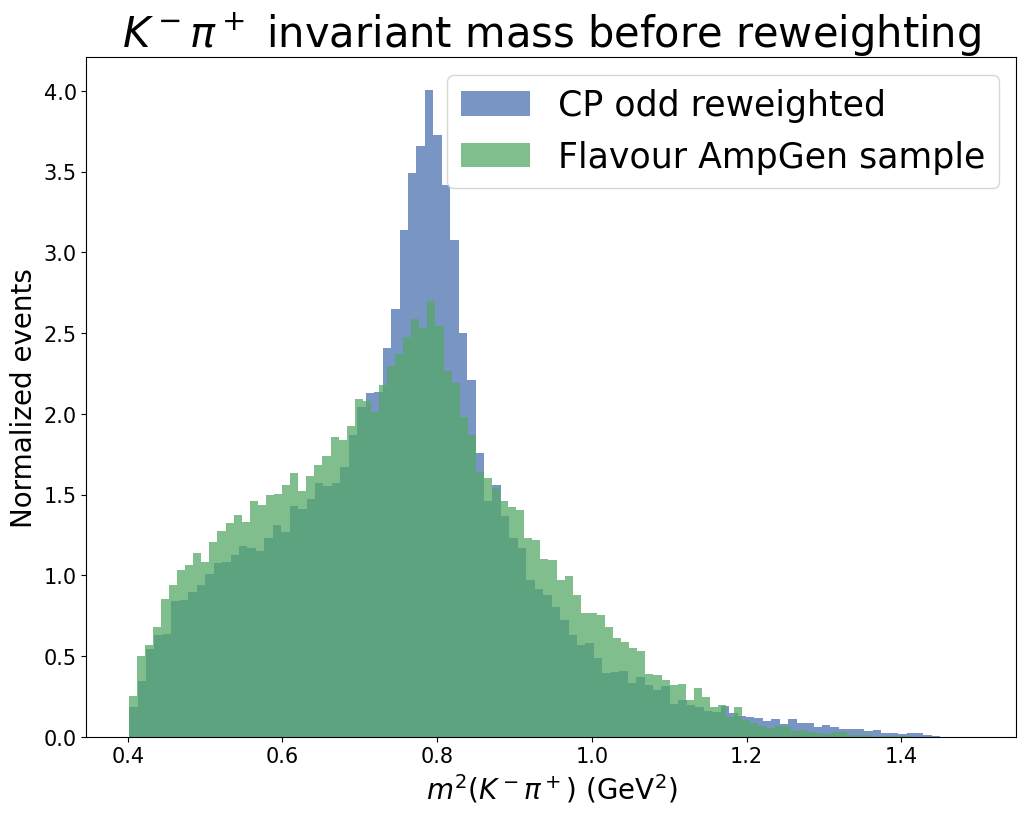

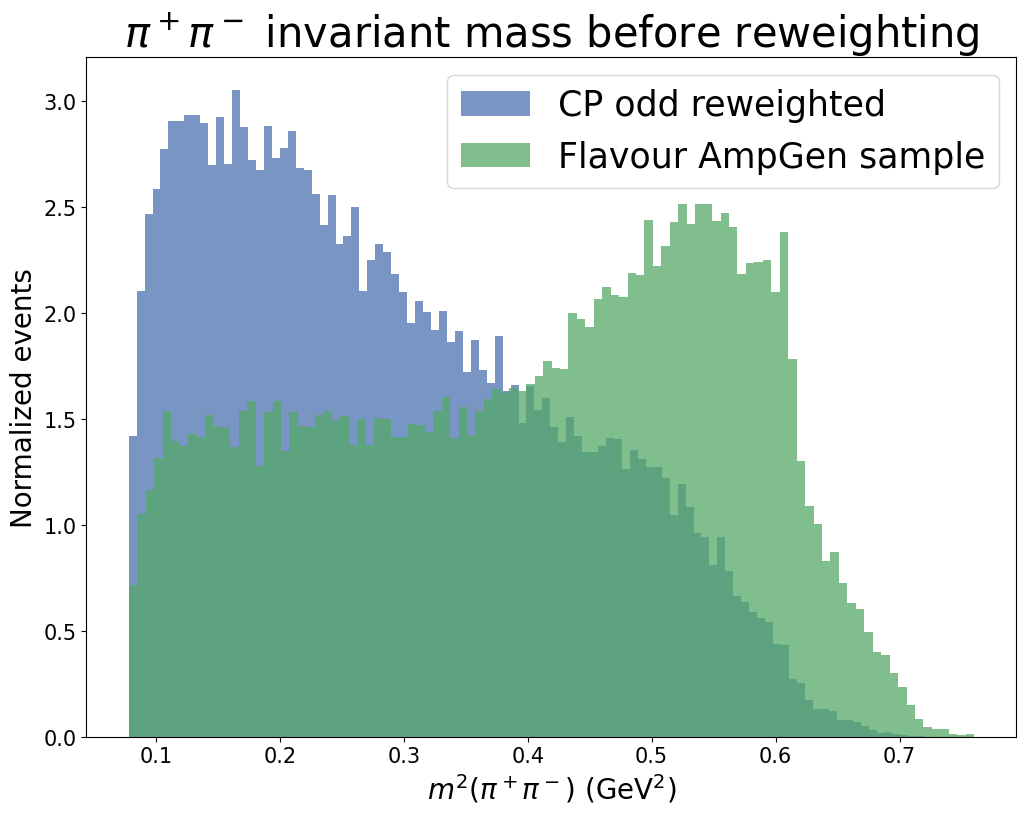

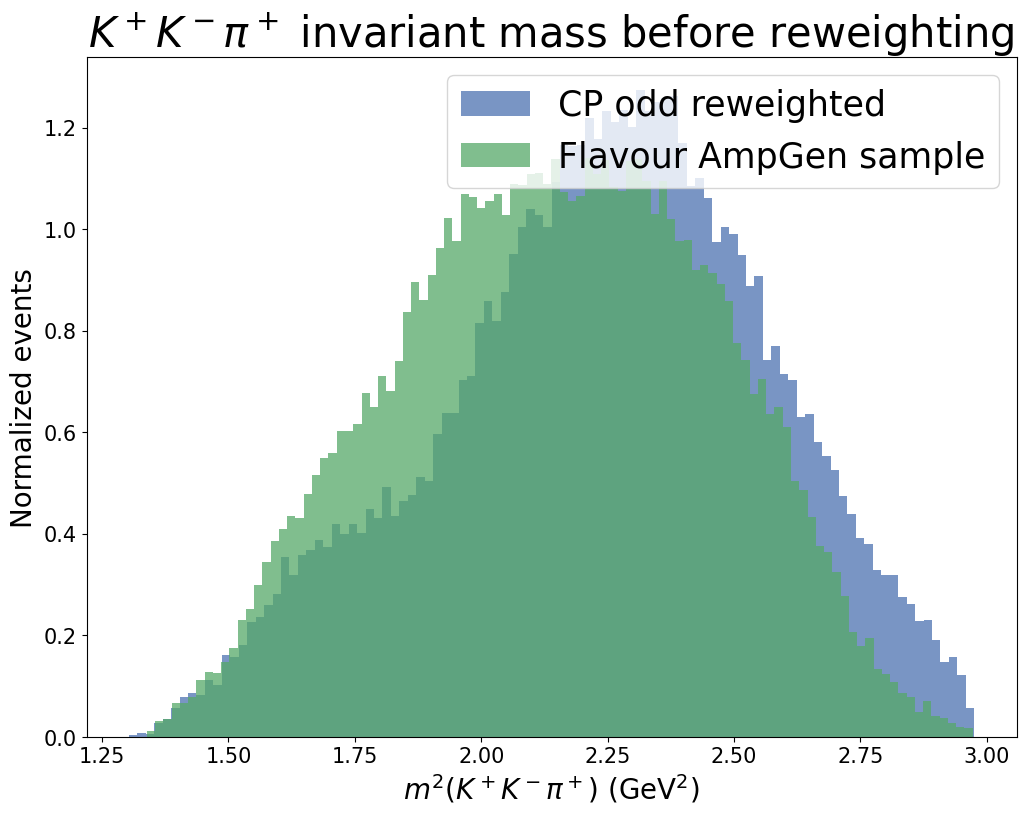

In [12]:
for key, value in Variables.items():
    plt.figure(figsize=(12, 9), dpi=100)
    plt.style.use('seaborn-deep')
    dummy = plt.hist(AmpGenCPOddArray_test[key], bins = 100, density = True, alpha = 0.75, label = 'CP odd reweighted')
    dummy = plt.hist(AmpGenArray_test[key], bins = 100, density = True, alpha = 0.75, label = 'Flavour AmpGen sample')
    plt.legend(loc='upper right', fontsize = 25)
    dummy = plt.title(r'$' + value + '$ invariant mass before reweighting', fontsize = 30)
    dummy = plt.xlabel(r'$m^2(' + value + ')$ (GeV$^2$)', fontsize = 20)
    dummy = plt.ylabel('Normalized events', fontsize = 20)
    dummy = plt.xticks(fontsize = 15)
    dummy = plt.yticks(fontsize = 15)
    plt.savefig(key + '_BeforeReweighting_CPOdd.png')
    plt.show()

### Check Kolmogorov-Smirnov distance for 1D projections after reweighting

In [13]:
for key in Variables:
    print('KS over ', key, ': ', ks_2samp_weighted(AmpGenCPEvenArray_test[key], AmpGenArray_test[key], weights1 = np.ones(len(AmpGenCPEvenArray_test), dtype=float), weights2 = BES3Weights_CPEven))

KS over  s01 :  0.004752456789406667
KS over  s03 :  0.00555145828834358
KS over  s12 :  0.008632839604799325
KS over  s23 :  0.006062332977899709
KS over  s012 :  0.005788070547553148


In [14]:
for key in Variables:
    print('KS over ', key, ': ', ks_2samp_weighted(AmpGenCPOddArray_test[key], AmpGenArray_test[key], weights1 = np.ones(len(AmpGenCPOddArray_test), dtype=float), weights2 = BES3Weights_CPOdd))

KS over  s01 :  0.005510152948946523
KS over  s03 :  0.006749990890665081
KS over  s12 :  0.008151579643709717
KS over  s23 :  0.005924035259192384
KS over  s012 :  0.01167565385604552


### Plot 1D projections after reweighting

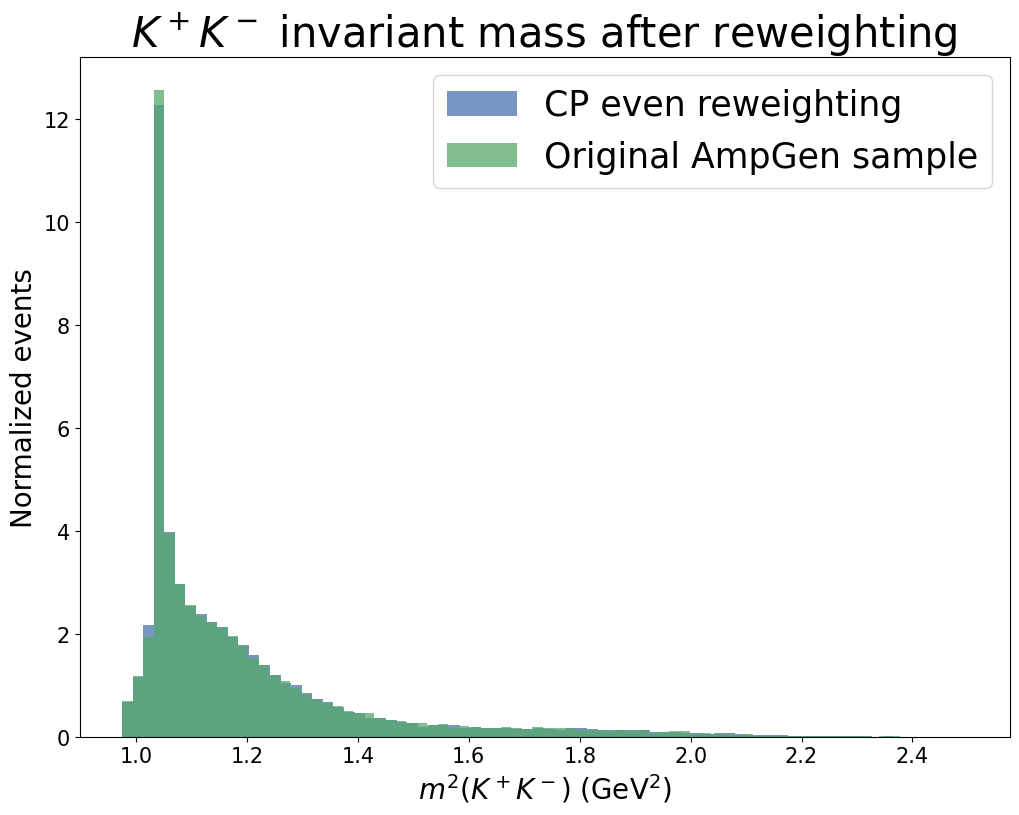

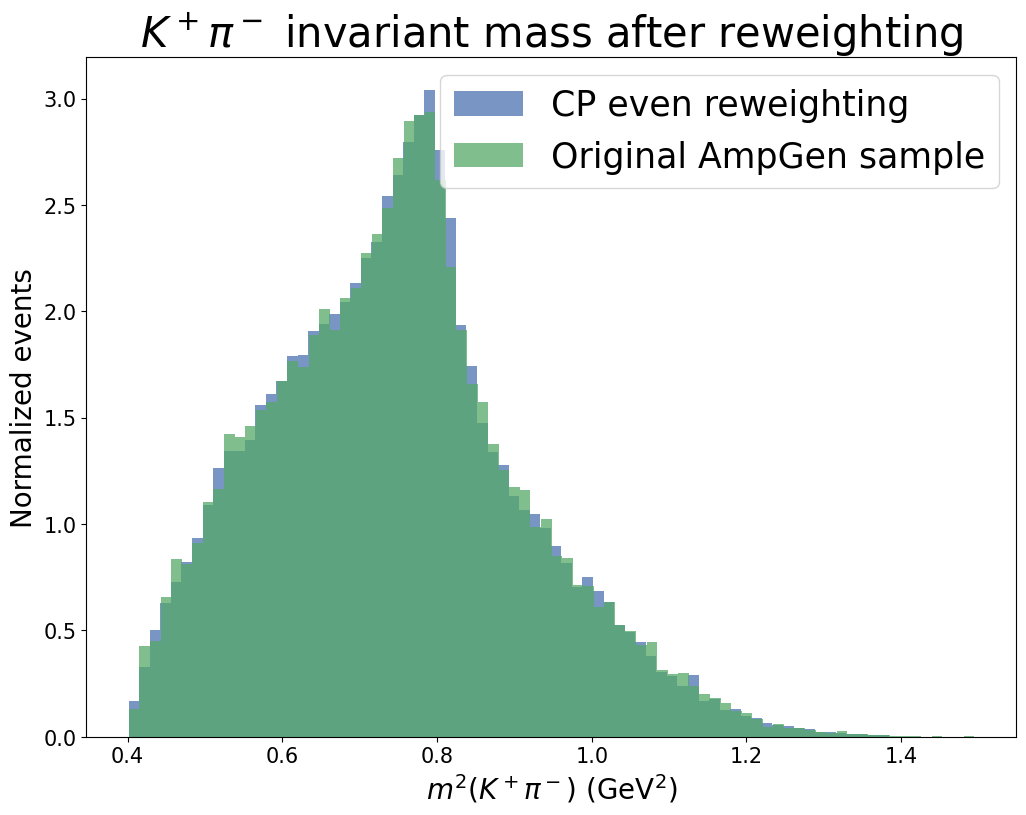

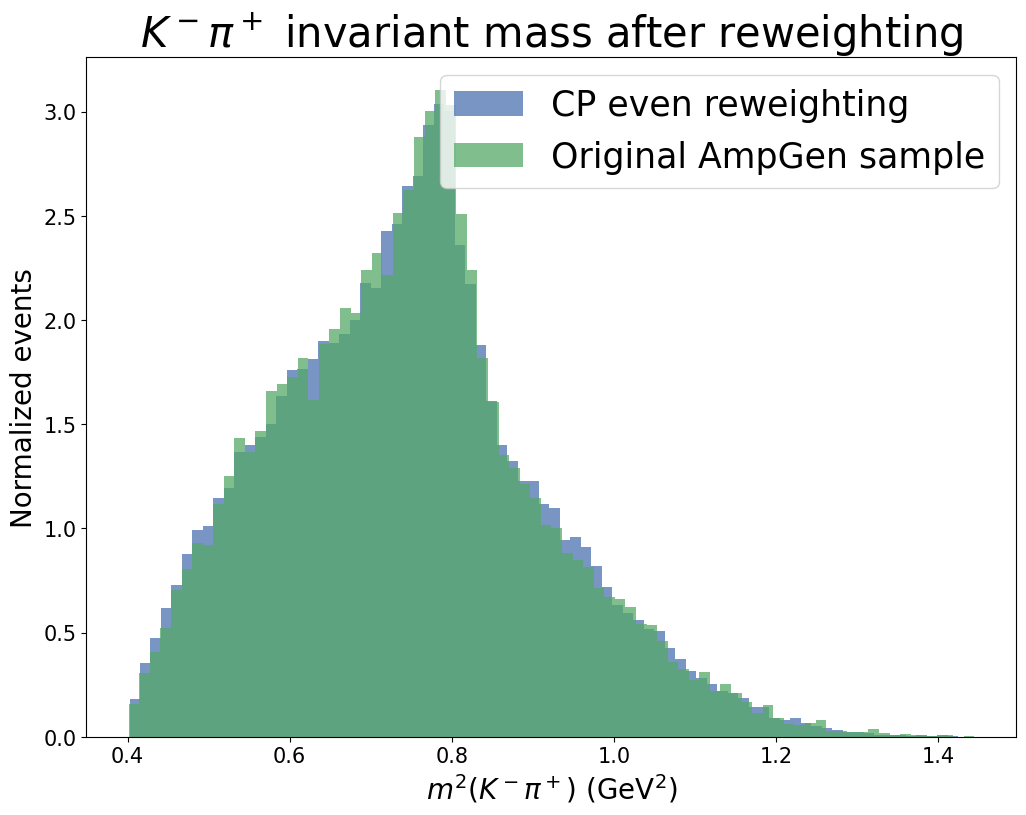

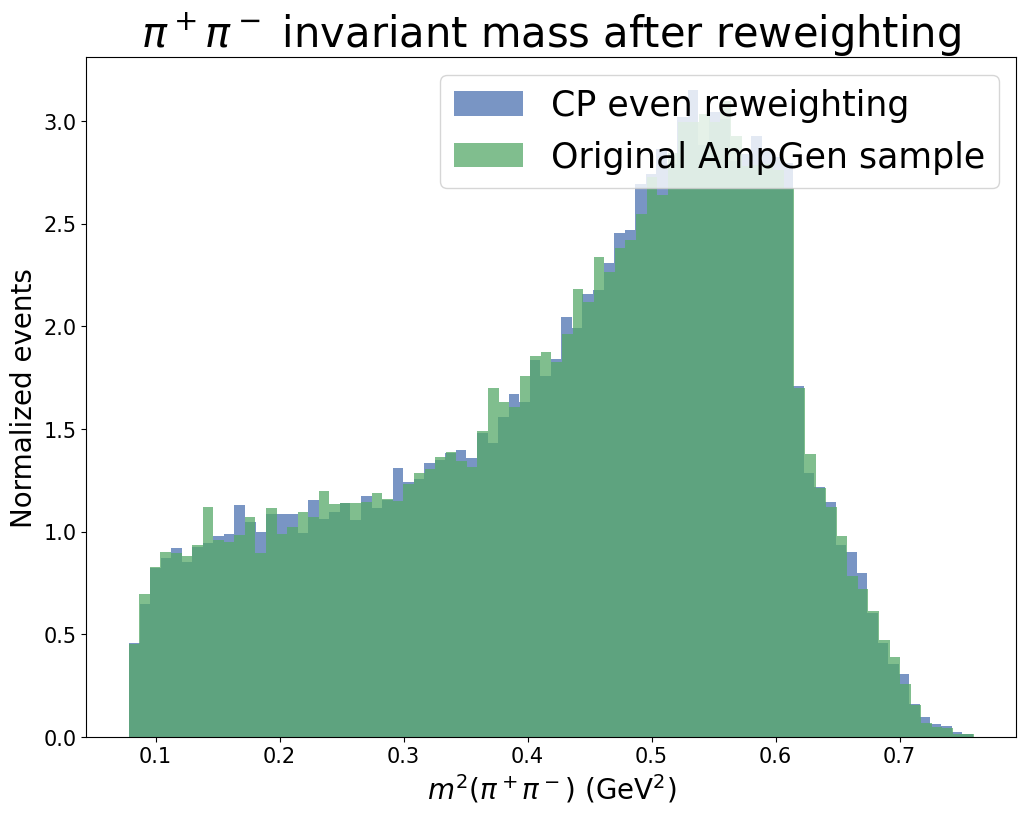

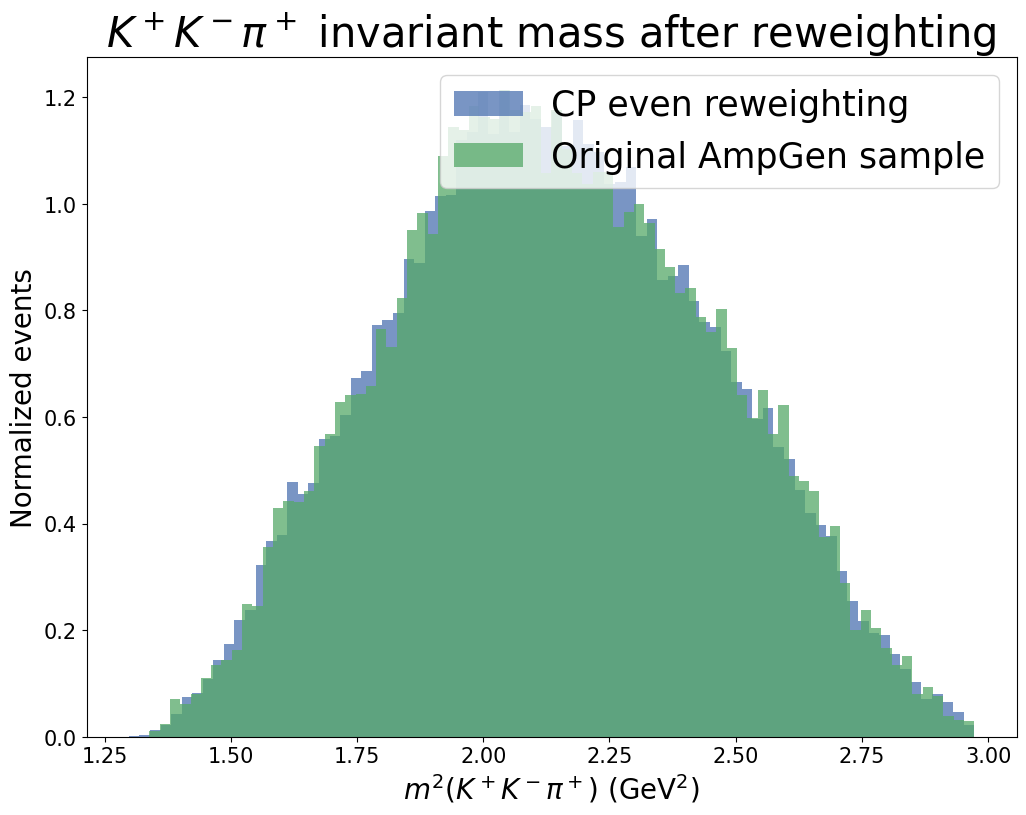

In [15]:
for key, value in Variables.items():
    plt.figure(figsize=(12, 9), dpi=100)
    plt.style.use('seaborn-deep')
    dummy = plt.hist(AmpGenCPEvenArray_test[key], bins = 80, density = True, alpha = 0.75, label = 'CP even reweighting')
    dummy = plt.hist(AmpGenArray_test[key], bins = 80, weights = BES3Weights_CPEven, density = True, alpha = 0.75, label = 'Original AmpGen sample')
    plt.legend(loc='upper right', fontsize = 25)
    dummy = plt.title(r'$' + value + '$ invariant mass after reweighting', fontsize = 30)
    dummy = plt.xlabel(r'$m^2(' + value + ')$ (GeV$^2$)', fontsize = 20)
    dummy = plt.ylabel('Normalized events', fontsize = 20)
    dummy = plt.xticks(fontsize = 15)
    dummy = plt.yticks(fontsize = 15)
    plt.savefig(key + '_AfterReweighting_CPEven.png')
    plt.show()

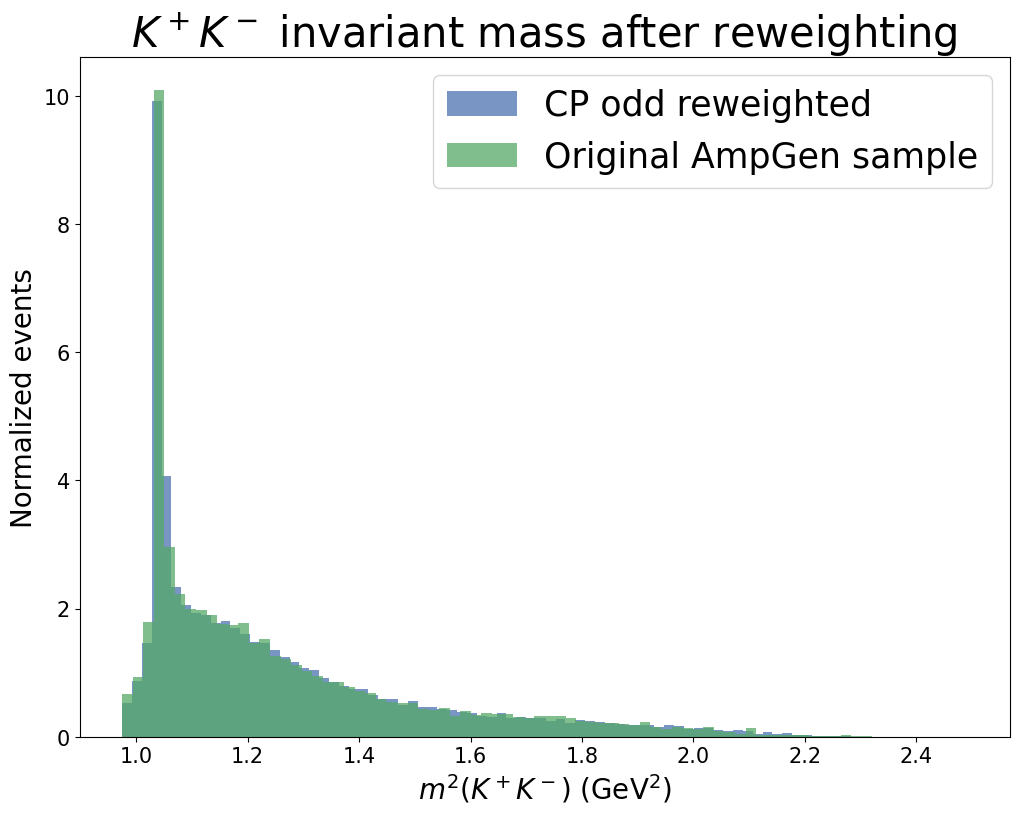

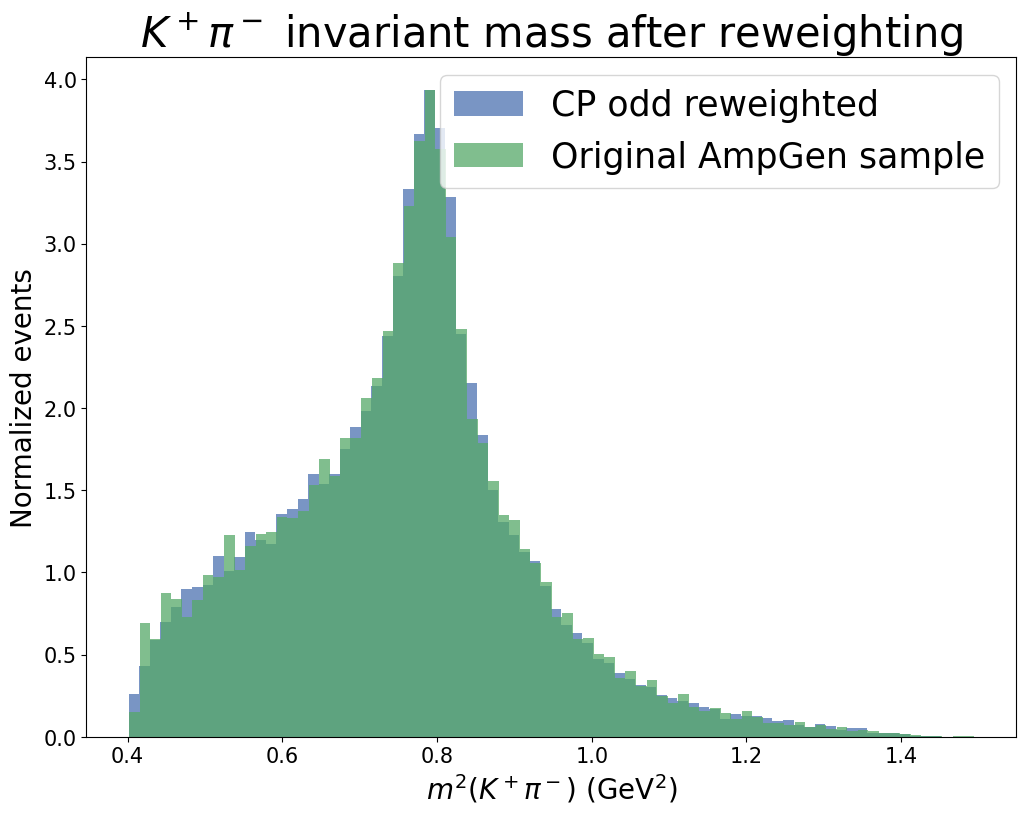

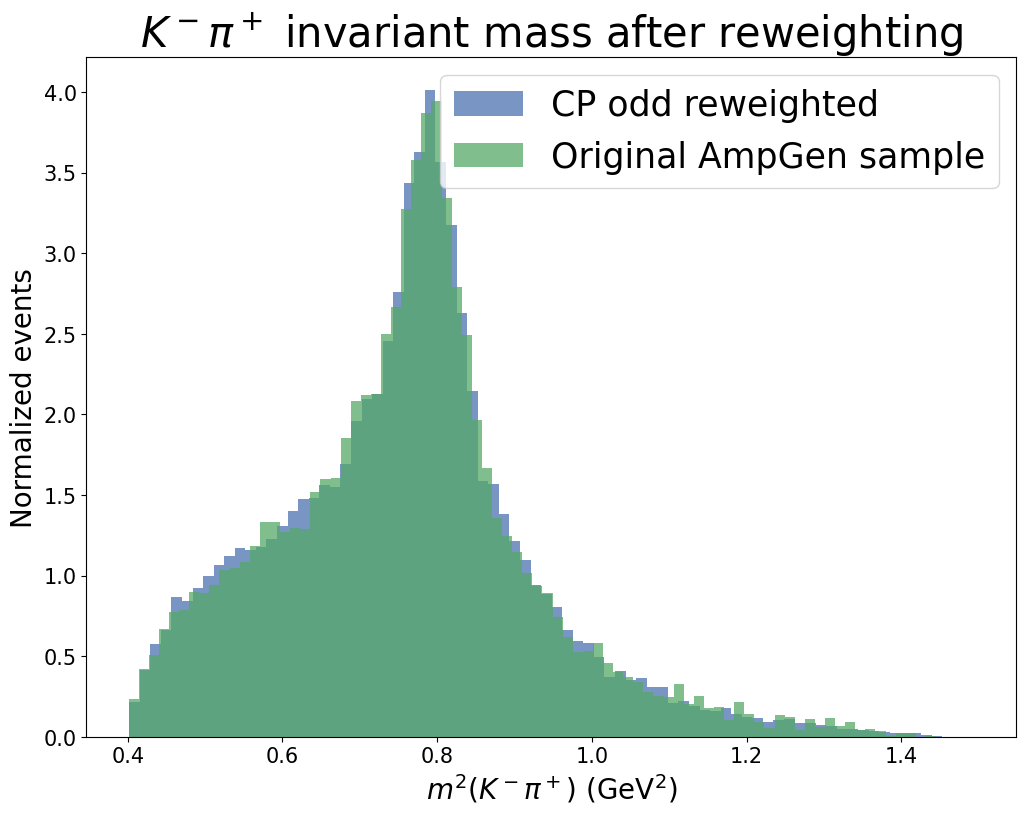

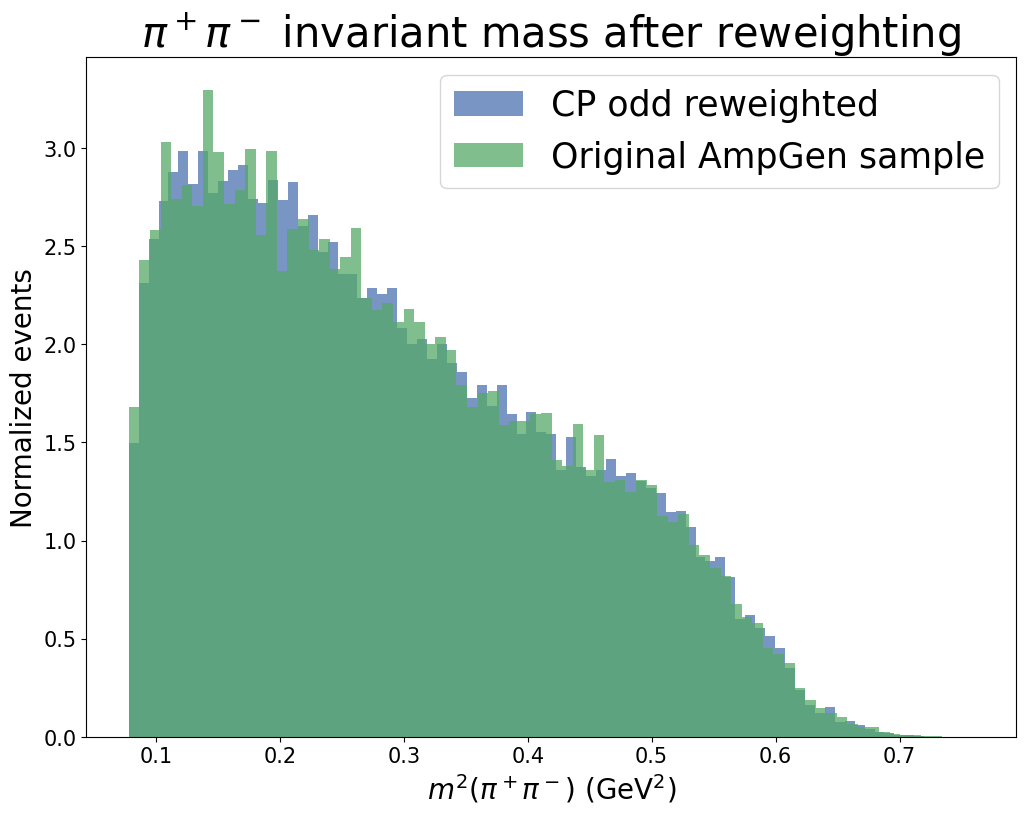

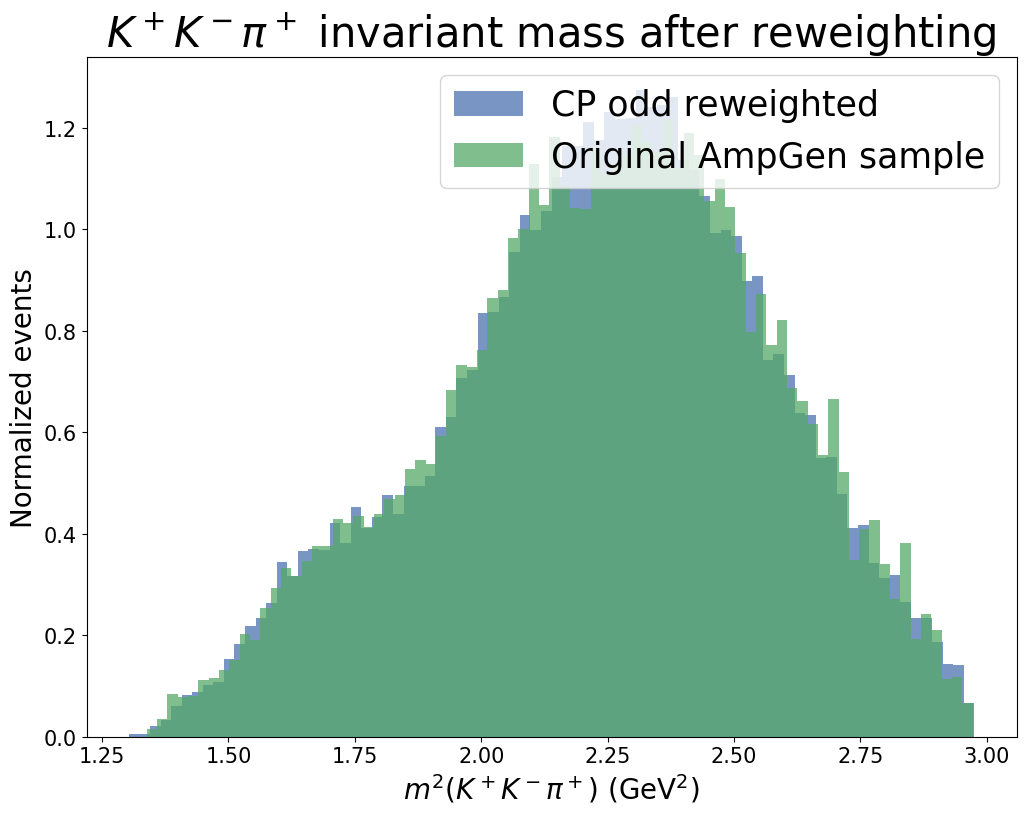

In [16]:
for key, value in Variables.items():
    plt.figure(figsize=(12, 9), dpi=100)
    plt.style.use('seaborn-deep')
    dummy = plt.hist(AmpGenCPOddArray_test[key], bins = 80, density = True, alpha = 0.75, label = 'CP odd reweighted')
    dummy = plt.hist(AmpGenArray_test[key], bins = 80, weights = BES3Weights_CPOdd, density = True, alpha = 0.75, label = 'Original AmpGen sample')
    plt.legend(loc='upper right', fontsize = 25)
    dummy = plt.title(r'$' + value + '$ invariant mass after reweighting', fontsize = 30)
    dummy = plt.xlabel(r'$m^2(' + value + ')$ (GeV$^2$)', fontsize = 20)
    dummy = plt.ylabel('Normalized events', fontsize = 20)
    dummy = plt.xticks(fontsize = 15)
    dummy = plt.yticks(fontsize = 15)
    plt.savefig(key + '_AfterReweighting_CPOdd.png')
    plt.show()

### Save reweighters to a file

In [17]:
with open('EfficiencyReweighter_CPEven.pkl', 'wb') as f:
    pickle.dump(reweighter_CPEven, f)

In [18]:
with open('EfficiencyReweighter_CPOdd.pkl', 'wb') as f:
    pickle.dump(reweighter_CPOdd, f)